In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.image as mpimg
from matplotlib.ticker import MultipleLocator, MaxNLocator

In [2]:
# READ IN THE CORE PROPERTIES (ORCA RESULTS)

# Read CSV with multi-level header
df = pd.read_excel("Core13.xlsx", header=0, skiprows=[1])

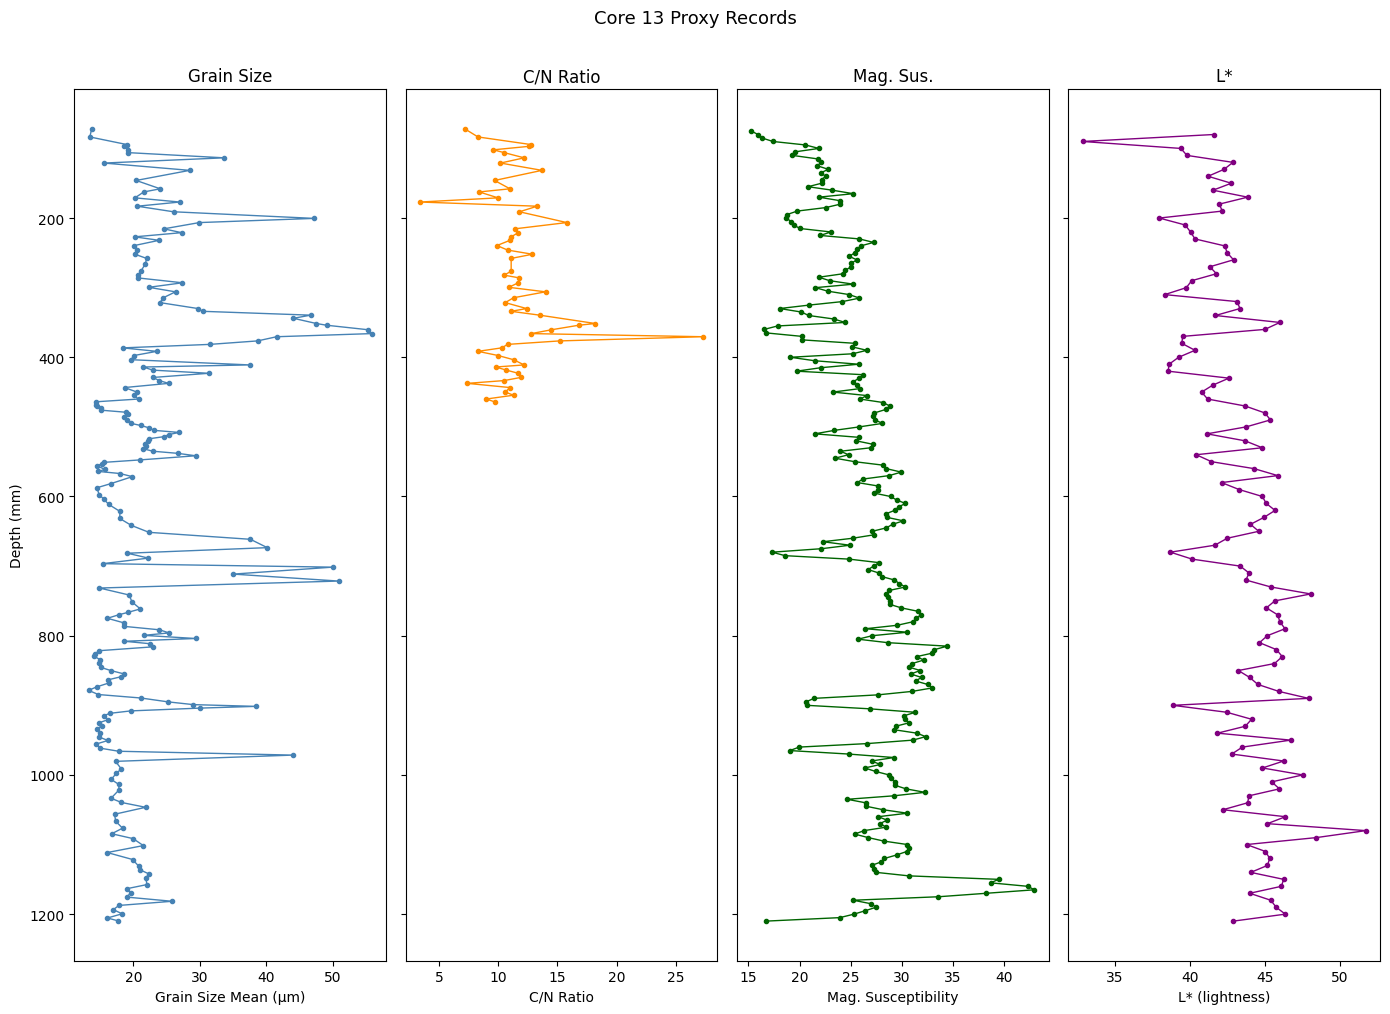

In [3]:
df.columns = [
    'Sample', 'Depth', 'DepthMidpoint',
    'ParticleWeight', 'CN_Weight', 'Epoch',
    'Mean', 'Sorting', 'Skewness', 'Kurtosis',
    'CN_Ratio',
    'MagDepth', 'MagSus',
    'L_Depth', 'L_star',
    'SIO'
]

# Clear breaking spaces in CN col
df['CN_Ratio'] = df['CN_Ratio'].replace('\xa0', '', regex=True)
df['CN_Ratio'] = pd.to_numeric(df['CN_Ratio'], errors='coerce')

# --- Separate proxy dataframes by their own depth columns ---
df_main  = df[['DepthMidpoint', 'Mean', 'CN_Ratio']].dropna(subset=['Mean'])
df_cn    = df[['DepthMidpoint', 'CN_Ratio']].dropna()
df_mag   = df[['MagDepth', 'MagSus']].dropna()
df_lstar = df[['L_Depth', 'L_star']].dropna()


# --- Build figure with 4 panels sharing Y axis ---
fig, axes = plt.subplots(1, 4, figsize=(14, 10), sharey=True)

# Panel 1: Grain size mean
axes[0].plot(df_main['Mean'], df_main['DepthMidpoint'], color='steelblue', linewidth=1, marker='o', markersize=3)
axes[0].set_xlabel('Grain Size Mean (µm)')
axes[0].set_ylabel('Depth (mm)')
axes[0].invert_yaxis()
axes[0].set_title('Grain Size')

# axes[0].fill_betweenx(df_main['DepthMidpoint'], df_main['Mean'].min(), df_main['Mean'], alpha=0.3, color='steelblue')
# axes[0].plot(df_main['Mean'], df_main['DepthMidpoint'], color='steelblue', linewidth=0.8)

# Panel 2: C/N Ratio
axes[1].plot(df_cn['CN_Ratio'], df_cn['DepthMidpoint'], color='darkorange', linewidth=1, marker='o', markersize=3)
axes[1].set_xlabel('C/N Ratio')
axes[1].set_title('C/N Ratio')

# axes[1].fill_betweenx(df_cn['DepthMidpoint'], df_cn['CN_Ratio'].min(), df_cn['CN_Ratio'], alpha=0.3, color='darkorange')
# axes[1].plot(df_cn['CN_Ratio'], df_cn['DepthMidpoint'], color='darkorange', linewidth=0.8)


# Panel 3: Magnetic Susceptibility
axes[2].plot(df_mag['MagSus'], df_mag['MagDepth'], color='darkgreen', linewidth=1, marker='o', markersize=3)
axes[2].set_xlabel('Mag. Susceptibility')
axes[2].set_title('Mag. Sus.')

# Panel 4: L* (lightness)
axes[3].plot(df_lstar['L_star'], df_lstar['L_Depth'], color='purple', linewidth=1, marker='o', markersize=3)
axes[3].set_xlabel('L* (lightness)')
axes[3].set_title('L*')



plt.suptitle('Core 13 Proxy Records', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('Core17_proxies.png', dpi=150, bbox_inches='tight')
plt.show()

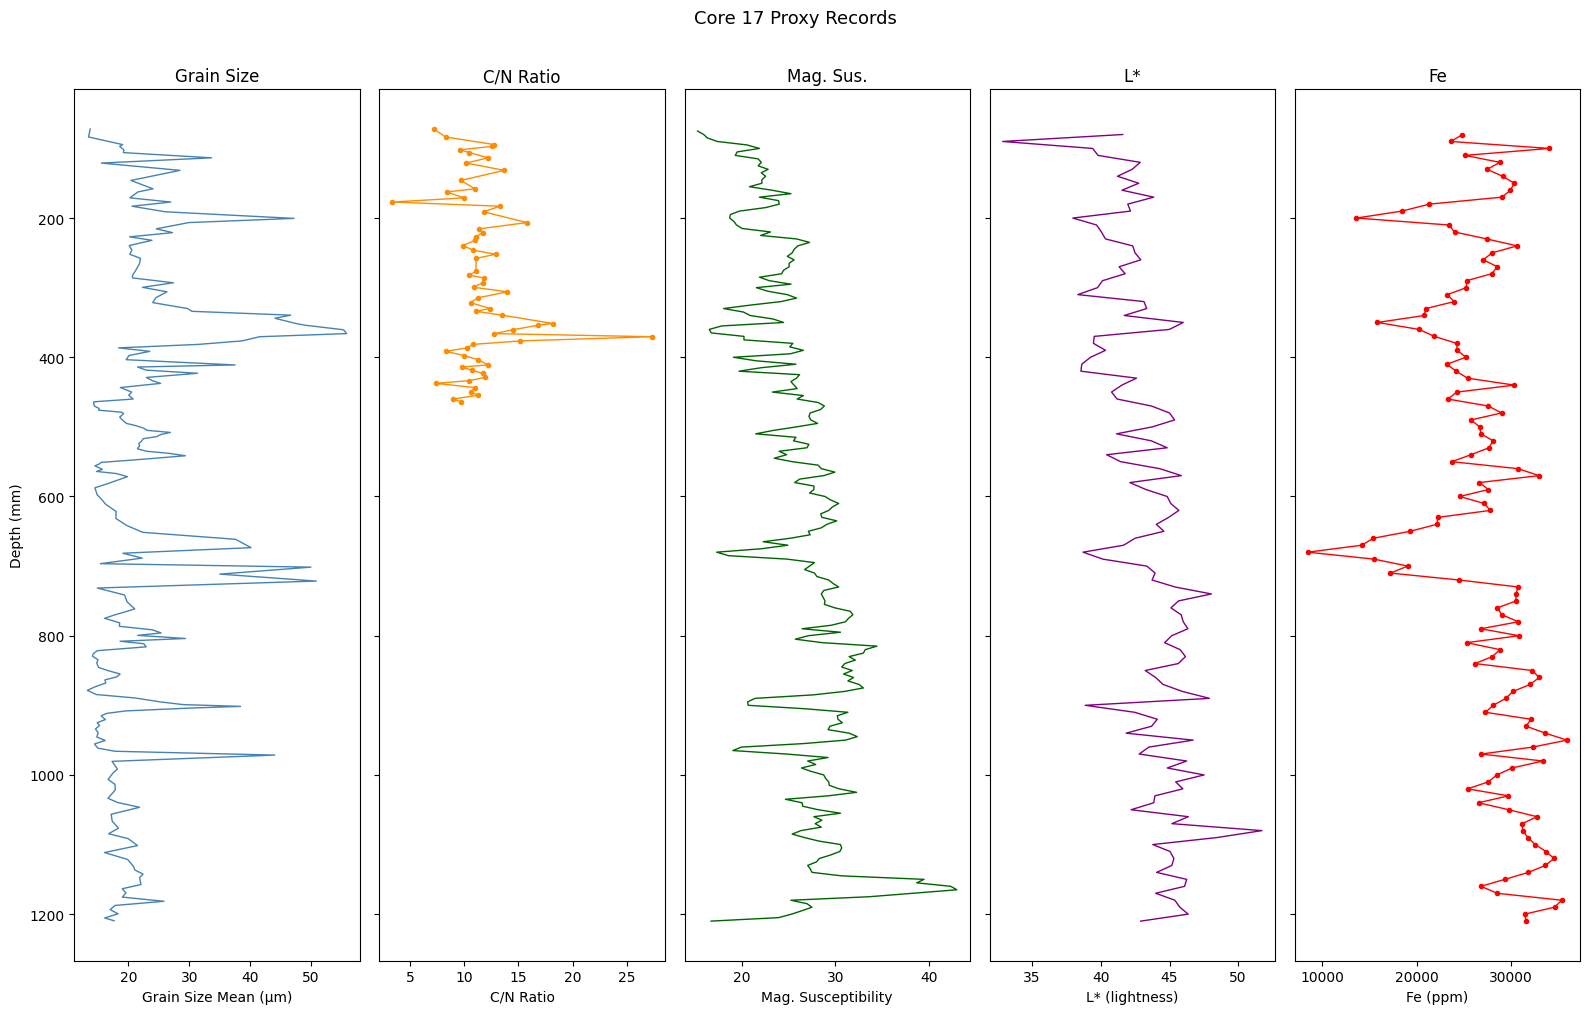

In [4]:
import numpy as np

df.columns = [
    'Sample', 'Depth', 'DepthMidpoint',
    'ParticleWeight', 'CN_Weight', 'Epoch',
    'Mean', 'Sorting', 'Skewness', 'Kurtosis',
    'CN_Ratio',
    'MagDepth', 'MagSus',
    'L_Depth', 'L_star',
    'Fe'
]

# ✅ Clean ALL whitespace/non-breaking spaces first, before anything else
df = df.replace(r'^\s+$', np.nan, regex=True)
df = df.replace('\xa0', np.nan, regex=True)

numeric_cols = ['DepthMidpoint', 'Mean', 'Sorting', 'Skewness', 'Kurtosis',
                'CN_Ratio', 'MagDepth', 'MagSus', 'L_Depth', 'L_star', 'Fe']
df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors='coerce')

# --- Separate proxy dataframes by their own depth columns ---
df_main  = df[['DepthMidpoint', 'Mean']].dropna()
df_cn    = df[['DepthMidpoint', 'CN_Ratio']].dropna()
df_mag   = df[['MagDepth', 'MagSus']].dropna()
df_lstar = df[['L_Depth', 'L_star']].dropna()
df_fe   = df[['MagDepth', 'Fe']].dropna()

# --- Build figure with 5 panels sharing Y axis ---
fig, axes = plt.subplots(1, 5, figsize=(16, 10), sharey=True)

# Panel 1: Grain size mean
axes[0].plot(df_main['Mean'], df_main['DepthMidpoint'], color='steelblue', linewidth=1)
axes[0].set_xlabel('Grain Size Mean (µm)')
axes[0].set_ylabel('Depth (mm)')
axes[0].invert_yaxis()
axes[0].set_title('Grain Size')

# Panel 2: C/N Ratio
axes[1].plot(df_cn['CN_Ratio'], df_cn['DepthMidpoint'], color='darkorange', linewidth=1, marker='o', markersize=3)
axes[1].set_xlabel('C/N Ratio')
axes[1].set_title('C/N Ratio')

# Panel 3: Magnetic Susceptibility
axes[2].plot(df_mag['MagSus'], df_mag['MagDepth'], color='darkgreen', linewidth=1)
axes[2].set_xlabel('Mag. Susceptibility')
axes[2].set_title('Mag. Sus.')

# Panel 4: L* (lightness)
axes[3].plot(df_lstar['L_star'], df_lstar['L_Depth'], color='purple', linewidth=1)
axes[3].set_xlabel('L* (lightness)')
axes[3].set_title('L*')

# Panel 5: SiO
axes[4].plot(df_fe['Fe'], df_fe['MagDepth'], color='red', linewidth=1, marker='o', markersize=3)
axes[4].set_xlabel('Fe (ppm)')
axes[4].set_title('Fe')

plt.suptitle('Core 17 Proxy Records', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('Core17_proxies.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
from matplotlib. import MinMaxScaler
import matplotlib.pyplot as plt
import matplotlib.lines as mlines

fig, ax = plt.subplots(figsize=(6, 12))

ax.plot(df_main['Mean'],   df_main['DepthMidpoint'], color='steelblue',  linewidth=0.8, alpha=0.8)
ax.plot(df_cn['CN_Ratio'],       df_cn['DepthMidpoint'],   color='darkorange', linewidth=0.8, alpha=0.8)
ax.plot(df_mag['MagSus'],     df_mag['MagDepth'],       color='darkgreen',  linewidth=0.8, alpha=0.8)
ax.plot(df_lstar['L_star'], df_lstar['L_Depth'],      color='purple',     linewidth=0.8, alpha=0.8)

ax.invert_yaxis()
ax.set_ylabel('Depth (mm)')
ax.set_xlabel('')
ax.set_title('Core 13 — All Proxies Overlaid')

# Manual legend
handles = [
    mlines.Line2D([], [], color='steelblue',  label='Grain Size Mean'),
    mlines.Line2D([], [], color='darkorange', label='C/N Ratio'),
    mlines.Line2D([], [], color='darkgreen',  label='Mag. Sus.'),
    mlines.Line2D([], [], color='purple',     label='L*'),
]
ax.legend(handles=handles, loc='lower right')

plt.tight_layout()
plt.savefig('Core17_overlaid.png', dpi=150, bbox_inches='tight')
plt.show()

ModuleNotFoundError: No module named 'sklearn'

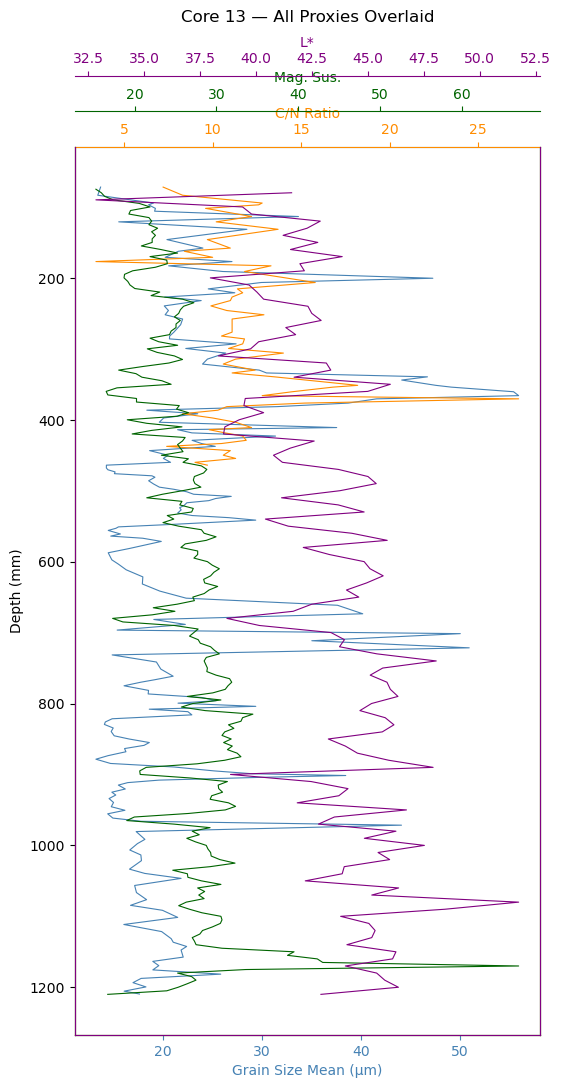

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.lines as mlines

fig, ax = plt.subplots(figsize=(6, 12))
fig.subplots_adjust(top=0.85)  # make room for stacked top spines

# --- Twin axes sharing Y ---
ax2 = ax.twiny()
ax3 = ax.twiny()
ax4 = ax.twiny()

# Offset the extra top spines so they don't overlap
# ax (bottom) is the base; ax2/3/4 stack above
ax3.spines['top'].set_position(('axes', 1.04))
ax4.spines['top'].set_position(('axes', 1.08))

# --- Plot each proxy on its own axis ---
l1, = ax.plot( df_main['Mean'],      df_main['DepthMidpoint'],  color='steelblue',  linewidth=0.8)
l2, = ax2.plot(df_cn['CN_Ratio'],    df_cn['DepthMidpoint'],    color='darkorange', linewidth=0.8)
l3, = ax3.plot(df_mag['MagSus'],     df_mag['MagDepth'],        color='darkgreen',  linewidth=0.8)
l4, = ax4.plot(df_lstar['L_star'],   df_lstar['L_Depth'],       color='purple',     linewidth=0.8)

# --- Colour each spine and tick to match its proxy ---
for spine in ax.spines.values():   spine.set_edgecolor('steelblue')
for spine in ax2.spines.values():  spine.set_edgecolor('darkorange')
for spine in ax3.spines.values():  spine.set_edgecolor('darkgreen')
for spine in ax4.spines.values():  spine.set_edgecolor('purple')

ax.tick_params(axis='x',  colors='steelblue')
ax2.tick_params(axis='x', colors='darkorange')
ax3.tick_params(axis='x', colors='darkgreen')
ax4.tick_params(axis='x', colors='purple')

# --- X axis labels, coloured to match ---
ax.set_xlabel('Grain Size Mean (µm)', color='steelblue')
ax2.set_xlabel('C/N Ratio',           color='darkorange')
ax3.set_xlabel('Mag. Sus.',           color='darkgreen')
ax4.set_xlabel('L*',                  color='purple')

# --- Shared Y ---
ax.invert_yaxis()
ax.set_ylabel('Depth (mm)')
ax.set_title('Core 13 — All Proxies Overlaid', pad=90)  # pad clears the stacked axes


plt.show()

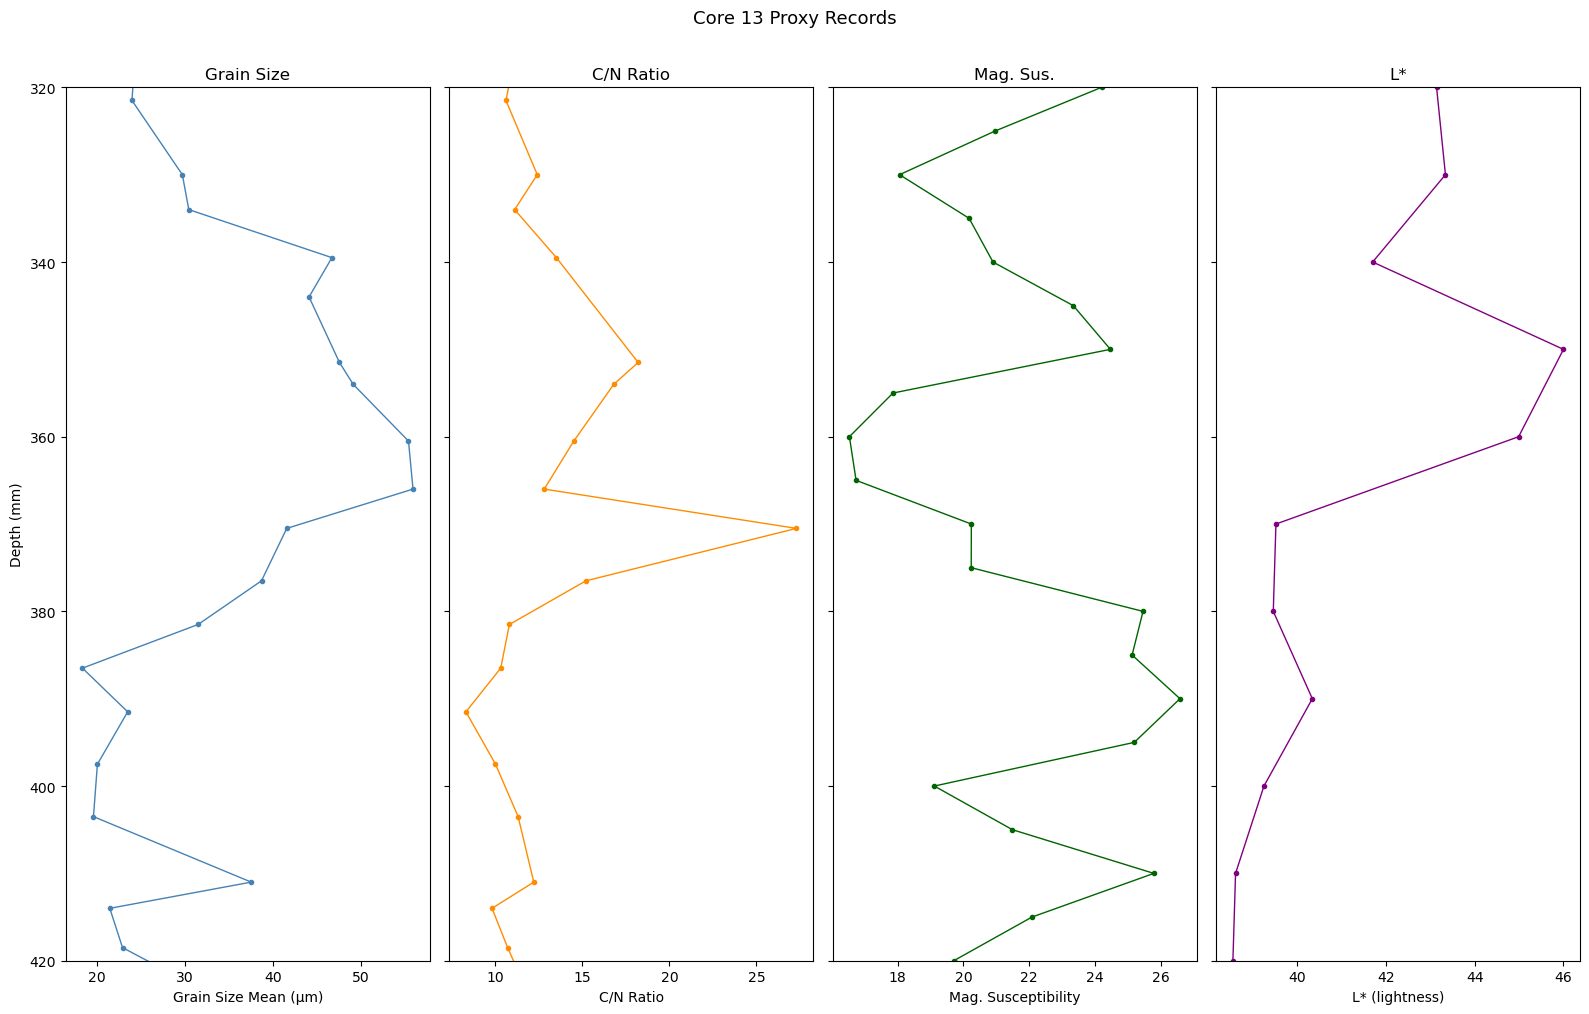

In [ ]:
import numpy as np

df.columns = [
    'Sample', 'Depth', 'DepthMidpoint',
    'ParticleWeight', 'CN_Weight', 'Epoch',
    'Mean', 'Sorting', 'Skewness', 'Kurtosis',
    'CN_Ratio',
    'MagDepth', 'MagSus',
    'L_Depth', 'L_star',
    'Fe'
]

# ✅ Clean ALL whitespace/non-breaking spaces first, before anything else
df = df.replace(r'^\s+$', np.nan, regex=True)
df = df.replace('\xa0', np.nan, regex=True)

numeric_cols = ['DepthMidpoint', 'Mean', 'Sorting', 'Skewness', 'Kurtosis',
                'CN_Ratio', 'MagDepth', 'MagSus', 'L_Depth', 'L_star', 'Fe']
df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors='coerce')

# --- Separate proxy dataframes by their own depth columns ---
df_main  = df[['DepthMidpoint', 'Mean']].dropna()
df_cn    = df[['DepthMidpoint', 'CN_Ratio']].dropna()
df_mag   = df[['MagDepth', 'MagSus']].dropna()
df_lstar = df[['L_Depth', 'L_star']].dropna()
# df_fe    = df[['MagDepth', 'Fe']].dropna()

# --- Build figure with 5 panels sharing Y axis ---
fig, axes = plt.subplots(1, 4, figsize=(16, 10), sharey=True)

# Panel 1: Grain size mean
axes[0].plot(df_main['Mean'], df_main['DepthMidpoint'], color='steelblue', linewidth=1, marker='o', markersize=3)
axes[0].set_xlabel('Grain Size Mean (µm)')
axes[0].set_ylabel('Depth (mm)')
axes[0].invert_yaxis()
axes[0].set_title('Grain Size')

# Panel 2: C/N Ratio
axes[1].plot(df_cn['CN_Ratio'], df_cn['DepthMidpoint'], color='darkorange', linewidth=1, marker='o', markersize=3)
axes[1].set_xlabel('C/N Ratio')
axes[1].set_title('C/N Ratio')

# Panel 3: Magnetic Susceptibility
axes[2].plot(df_mag['MagSus'], df_mag['MagDepth'], color='darkgreen', linewidth=1, marker='o', markersize=3)
axes[2].set_xlabel('Mag. Susceptibility')
axes[2].set_title('Mag. Sus.')

# Panel 4: L* (lightness)
axes[3].plot(df_lstar['L_star'], df_lstar['L_Depth'], color='purple', linewidth=1, marker='o', markersize=3)
axes[3].set_xlabel('L* (lightness)')
axes[3].set_title('L*')

plt.ylim(420,320)

# --- Rescale X axes to only the visible Y window ---
y_min, y_max = axes[0].get_ylim()  # inverted, so y_min > y_max
y_lo = min(y_min, y_max)
y_hi = max(y_min, y_max)

def rescale_x(ax, x_series, y_series):
    mask = (y_series >= y_lo) & (y_series <= y_hi)
    visible_x = x_series[mask]
    if visible_x.empty:
        return
    pad = (visible_x.max() - visible_x.min()) * 0.05  # 5% padding
    ax.set_xlim(visible_x.min() - pad, visible_x.max() + pad)

rescale_x(axes[0], df_main['Mean'],    df_main['DepthMidpoint'])
rescale_x(axes[1], df_cn['CN_Ratio'],  df_cn['DepthMidpoint'])
rescale_x(axes[2], df_mag['MagSus'],   df_mag['MagDepth'])
rescale_x(axes[3], df_lstar['L_star'], df_lstar['L_Depth'])

plt.suptitle('Core 13 Proxy Records', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('Core17_proxies.png', dpi=150, bbox_inches='tight')
plt.show()